In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.datasets import Planetoid
from torch.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
import time

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0].to(device)

# Print some statistics about the dataset
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features: {data.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of training nodes: {data.train_mask.sum().item()}")
print(f"Number of validation nodes: {data.val_mask.sum().item()}")
print(f"Number of test nodes: {data.test_mask.sum().item()}")

Using device: cpu


Processing...


Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7
Number of training nodes: 140
Number of validation nodes: 500
Number of test nodes: 1000


Done!


In [4]:
# Define the GAT model
class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super(GATNet, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        # On the output layer, we use a single head
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # Apply first GAT layer with multiple attention heads
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)

        # Apply second GAT layer with a single attention head
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)

        return x

# Define the GCN model for comparison
class GCNNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GCNNet, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Define a function to train the model
def train_model(model, data, optimizer, epochs=200, eval_every=10):
    model.train()
    train_losses = []
    val_accuracies = []

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if (epoch + 1) % eval_every == 0:
            val_acc = evaluate(model, data, data.val_mask)
            val_accuracies.append(val_acc)
            print(f"Epoch: {epoch+1}, Loss: {loss.item():.4f}, Val Accuracy: {val_acc:.4f}")

            # Save the best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}

    # Load the best model
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

    return train_losses, val_accuracies

In [5]:
# Define a function to evaluate the model
def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        accuracy = int(correct.sum()) / int(mask.sum())
    return accuracy

# Function to plot training curves
def plot_training_curves(train_losses, val_accuracies, eval_every):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(eval_every, len(train_losses) + 1, eval_every), val_accuracies)
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

In [6]:
# Function to compare models
def compare_models(data, hidden_channels=8, epochs=200):
    results = {}
    models = {
        'GAT': GATNet(data.num_features, hidden_channels, dataset.num_classes),
        'GCN': GCNNet(data.num_features, hidden_channels, dataset.num_classes)
    }

    for name, model in models.items():
        print(f"\n--- Training {name} model ---")
        model = model.to(device)
        optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

        start_time = time.time()
        train_losses, val_accuracies = train_model(model, data, optimizer, epochs=epochs)
        training_time = time.time() - start_time

        test_acc = evaluate(model, data, data.test_mask)

        results[name] = {
            'test_accuracy': test_acc,
            'training_time': training_time,
            'num_parameters': sum(p.numel() for p in model.parameters()),
            'train_losses': train_losses,
            'val_accuracies': val_accuracies
        }

        print(f"{name} Test Accuracy: {test_acc:.4f}")
        print(f"{name} Training Time: {training_time:.2f} seconds")
        print(f"{name} Number of Parameters: {results[name]['num_parameters']}")

    return results


--- Training GAT model ---
Epoch: 10, Loss: 0.9796, Val Accuracy: 0.7600
Epoch: 20, Loss: 0.1086, Val Accuracy: 0.7740
Epoch: 30, Loss: 0.0152, Val Accuracy: 0.7700
Epoch: 40, Loss: 0.0045, Val Accuracy: 0.7600
Epoch: 50, Loss: 0.0033, Val Accuracy: 0.7600
Epoch: 60, Loss: 0.0036, Val Accuracy: 0.7620
Epoch: 70, Loss: 0.0046, Val Accuracy: 0.7660
Epoch: 80, Loss: 0.0057, Val Accuracy: 0.7700
Epoch: 90, Loss: 0.0062, Val Accuracy: 0.7780
Epoch: 100, Loss: 0.0063, Val Accuracy: 0.7760
Epoch: 110, Loss: 0.0062, Val Accuracy: 0.7760
Epoch: 120, Loss: 0.0059, Val Accuracy: 0.7720
Epoch: 130, Loss: 0.0057, Val Accuracy: 0.7720
Epoch: 140, Loss: 0.0055, Val Accuracy: 0.7780
Epoch: 150, Loss: 0.0053, Val Accuracy: 0.7740
Epoch: 160, Loss: 0.0051, Val Accuracy: 0.7780
Epoch: 170, Loss: 0.0050, Val Accuracy: 0.7760
Epoch: 180, Loss: 0.0048, Val Accuracy: 0.7800
Epoch: 190, Loss: 0.0046, Val Accuracy: 0.7800
Epoch: 200, Loss: 0.0045, Val Accuracy: 0.7800
GAT Test Accuracy: 0.8000
GAT Training Ti

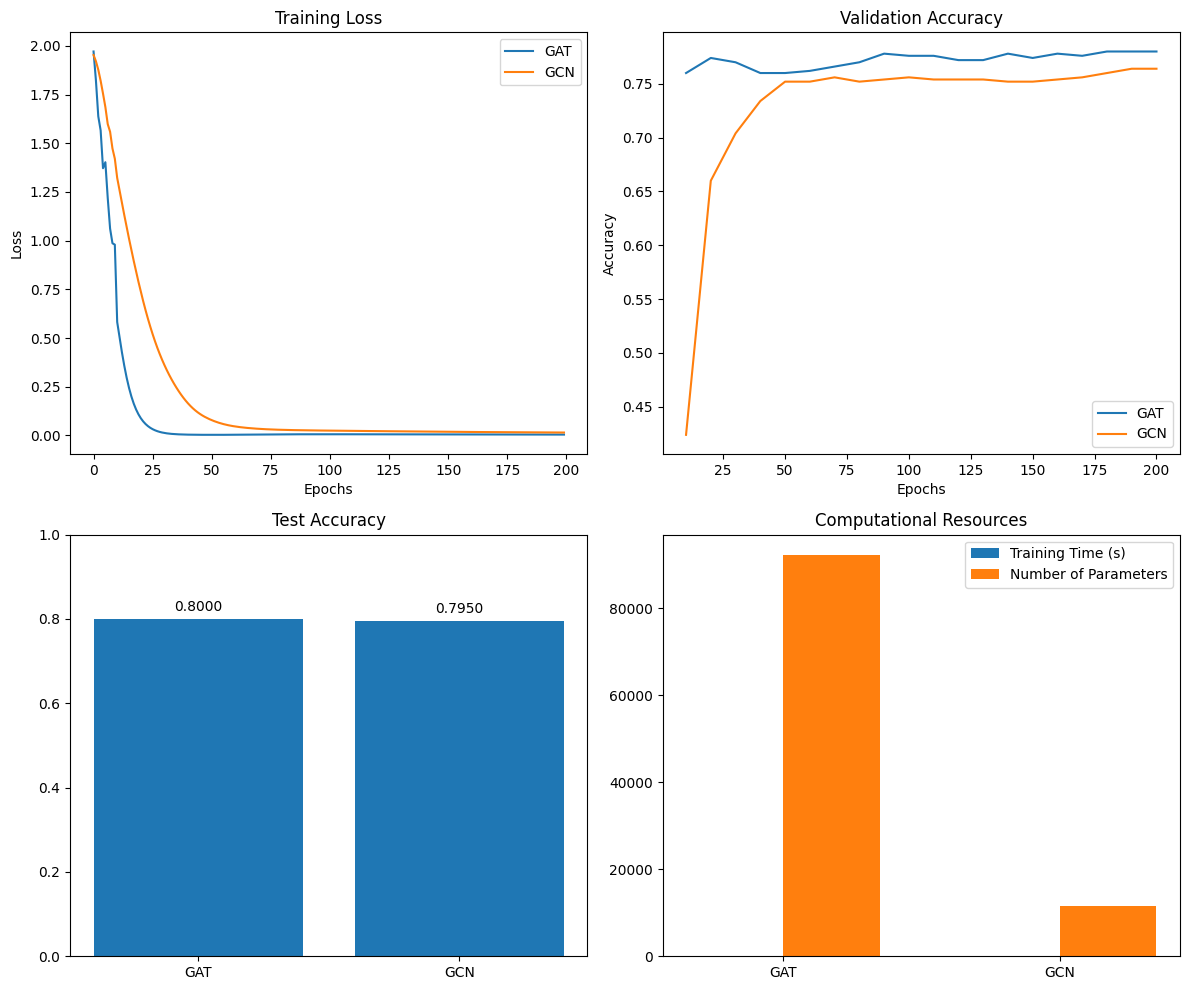

In [7]:
# Main execution
if __name__ == "__main__":
    # Hyperparameters
    hidden_channels = 8

    # Compare GAT and GCN
    results = compare_models(data, hidden_channels=hidden_channels)

    # Print comparison summary
    print("\n--- Model Comparison ---")
    for name, result in results.items():
        print(f"{name}:")
        print(f"  Test Accuracy: {result['test_accuracy']:.4f}")
        print(f"  Training Time: {result['training_time']:.2f} seconds")
        print(f"  Number of Parameters: {result['num_parameters']}")

    # Plot results for both models
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    for name, result in results.items():
        plt.plot(result['train_losses'], label=name)
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 2)
    for name, result in results.items():
        plt.plot(np.arange(10, 201, 10), result['val_accuracies'], label=name)
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 2, 3)
    names = list(results.keys())
    accuracies = [result['test_accuracy'] for result in results.values()]
    plt.bar(names, accuracies)
    plt.title('Test Accuracy')
    plt.ylim(0, 1)
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center')

    plt.subplot(2, 2, 4)
    times = [result['training_time'] for result in results.values()]
    params = [result['num_parameters'] for result in results.values()]
    width = 0.35
    x = np.arange(len(names))
    plt.bar(x - width/2, times, width, label='Training Time (s)')
    plt.bar(x + width/2, params, width, label='Number of Parameters')
    plt.title('Computational Resources')
    plt.xticks(x, names)
    plt.legend()

    plt.tight_layout()
    plt.show()